In [2]:
import os, json, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras

from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression

# XGBoost (Colab usually has it; install if missing)
try:
    from xgboost import XGBClassifier
    HAS_XGB = True
except ImportError:
    !pip install -q xgboost
    from xgboost import XGBClassifier
    HAS_XGB = True

from google.colab import drive
drive.mount('/content/drive')

PROJECT = '/content/drive/MyDrive/oruntu_tanima_proje'
PREP_DIR    = os.path.join(PROJECT, 'veri_hazirlik')
METHOD2_DIR = os.path.join(PROJECT, 'yontemler', 'yontem2')
FEAT_DIR    = os.path.join(METHOD2_DIR, 'features')
GRAPHS_DIR  = os.path.join(METHOD2_DIR, 'grafikler')
os.makedirs(FEAT_DIR, exist_ok=True)
os.makedirs(GRAPHS_DIR, exist_ok=True)

print('GPU:', tf.config.list_physical_devices('GPU'))

# Method 2 uses ALL 3000 labelled images for 5-Fold CV (no separate hold-out).
# We still use split_index.json to enumerate all files consistently.
with open(os.path.join(PREP_DIR, 'split_index.json')) as f:
    split = json.load(f)

all_files, all_labels = [], []
for part in ['train', 'val', 'test']:
    for cls, label in [('yes', 1), ('no', 0)]:
        for rel in split[part][cls]:
            all_files.append(os.path.join(PROJECT, rel))
            all_labels.append(label)

all_labels = np.array(all_labels)
print(f'Total images: {len(all_files)}  |  yes={sum(all_labels==1)}  no={sum(all_labels==0)}')

Mounted at /content/drive
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
Total images: 3000  |  yes=1500  no=1500


In [3]:
IMG_SIZE = 224
BATCH_SIZE = 32
AUTOTUNE = tf.data.AUTOTUNE

def make_inference_ds(filepaths, preprocess_fn):
    """Build a tf.data pipeline for inference (no shuffle, no augmentation)."""
    ds = tf.data.Dataset.from_tensor_slices(filepaths)
    def load(path):
        img = tf.io.read_file(path)
        img = tf.io.decode_image(img, channels=3, expand_animations=False)
        img = tf.image.resize(img, (IMG_SIZE, IMG_SIZE))
        img = tf.cast(img, tf.float32)
        img = preprocess_fn(img)
        return img
    return ds.map(load, num_parallel_calls=AUTOTUNE).batch(BATCH_SIZE).prefetch(AUTOTUNE)

def extract_features(backbone, preprocess_fn, filepaths, model_name):
    """Extract features from a frozen backbone. Print layer name + dimension."""
    inputs = keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
    x = backbone(inputs, training=False)
    if len(x.shape) == 4:
        x = keras.layers.GlobalAveragePooling2D(name='gap')(x)
    extractor = keras.Model(inputs, x, name=f'{model_name}_extractor')

    # ---- TRANSPARENCY: layer + dimension printout ----
    feature_dim = extractor.output_shape[-1]
    last_backbone_layer = backbone.layers[-1].name
    print(f'\n--- {model_name} feature extractor ---')
    print(f'  Backbone last layer : {last_backbone_layer}')
    print(f'  Pooling layer       : GlobalAveragePooling2D ("gap")')
    print(f'  Feature dimension   : {feature_dim}')

    ds = make_inference_ds(filepaths, preprocess_fn)
    t0 = time.perf_counter()
    feats = extractor.predict(ds, verbose=1)
    elapsed = time.perf_counter() - t0
    print(f'  Extracted shape     : {feats.shape}  (in {elapsed:.1f}s)')
    return feats, {
        'model': model_name,
        'backbone_last_layer': last_backbone_layer,
        'pooling': 'GlobalAveragePooling2D',
        'feature_dim': int(feature_dim),
        'n_samples': int(feats.shape[0]),
        'extract_time_sec': float(elapsed),
    }

labels_path = os.path.join(FEAT_DIR, 'labels.npy')
np.save(labels_path, all_labels)
print(f'Labels saved: {labels_path}  shape={all_labels.shape}')

fe_metadata = []

Labels saved: /content/drive/MyDrive/oruntu_tanima_proje/yontemler/yontem2/features/labels.npy  shape=(3000,)


In [ ]:
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.applications.efficientnet import preprocess_input as effnet_pp

MODEL_NAME = 'efficientnetb0'
backbone = EfficientNetB0(include_top=False, weights='imagenet',
                          input_shape=(IMG_SIZE, IMG_SIZE, 3))
backbone.trainable = False

feats, meta = extract_features(backbone, effnet_pp, all_files, MODEL_NAME)
np.save(os.path.join(FEAT_DIR, f'feat_{MODEL_NAME}.npy'), feats)
fe_metadata.append(meta)

# Save metadata JSON (cumulative; saved after every backbone)
with open(os.path.join(FEAT_DIR, 'fe_metadata.json'), 'w') as f:
    json.dump(fe_metadata, f, indent=2)
print(f'Saved: feat_{MODEL_NAME}.npy + fe_metadata.json')

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step

--- efficientnetb0 feature extractor ---
  Backbone last layer : top_activation
  Pooling layer       : GlobalAveragePooling2D ("gap")
  Feature dimension   : 1280
94/94 ━━━━━━━━━━━━━━━━━━━━ 432s 4s/step
  Extracted shape     : (3000, 1280)  (in 432.2s)
Saved: feat_efficientnetb0.npy + fe_metadata.json


In [ ]:
from tensorflow.keras.applications import (
    Xception, InceptionV3, VGG19, ResNet101, DenseNet121
)
from tensorflow.keras.applications.xception   import preprocess_input as xception_pp
from tensorflow.keras.applications.inception_v3 import preprocess_input as inception_pp
from tensorflow.keras.applications.vgg19      import preprocess_input as vgg19_pp
from tensorflow.keras.applications.resnet     import preprocess_input as resnet_pp
from tensorflow.keras.applications.densenet   import preprocess_input as densenet_pp

remaining_backbones = [
    ('xception',    Xception,    xception_pp),
    ('inceptionv3', InceptionV3, inception_pp),
    ('vgg19',       VGG19,       vgg19_pp),
    ('resnet101',   ResNet101,   resnet_pp),
    ('densenet121', DenseNet121, densenet_pp),
]

for name, BackboneClass, pp in remaining_backbones:
    backbone = BackboneClass(include_top=False, weights='imagenet',
                              input_shape=(IMG_SIZE, IMG_SIZE, 3))
    backbone.trainable = False
    feats, meta = extract_features(backbone, pp, all_files, name)
    np.save(os.path.join(FEAT_DIR, f'feat_{name}.npy'), feats)
    fe_metadata.append(meta)
    with open(os.path.join(FEAT_DIR, 'fe_metadata.json'), 'w') as f:
        json.dump(fe_metadata, f, indent=2)
    print(f'Saved: feat_{name}.npy\n')

# Summary table
print('\n=== Feature Extraction Summary ===')
df_fe = pd.DataFrame(fe_metadata)[
    ['model', 'backbone_last_layer', 'feature_dim', 'n_samples', 'extract_time_sec']
]
print(df_fe.to_string(index=False))

83683744/83683744 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step

--- xception feature extractor ---
  Backbone last layer : block14_sepconv2_act
  Pooling layer       : GlobalAveragePooling2D ("gap")
  Feature dimension   : 2048
94/94 ━━━━━━━━━━━━━━━━━━━━ 49s 310ms/step
  Extracted shape     : (3000, 2048)  (in 49.4s)
Saved: feat_xception.npy

87910968/87910968 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step

--- inceptionv3 feature extractor ---
  Backbone last layer : mixed10
  Pooling layer       : GlobalAveragePooling2D ("gap")
  Feature dimension   : 2048
94/94 ━━━━━━━━━━━━━━━━━━━━ 31s 222ms/step
  Extracted shape     : (3000, 2048)  (in 31.3s)
Saved: feat_inceptionv3.npy

80134624/80134624 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step

--- vgg19 feature extractor ---
  Backbone last layer : block5_pool
  Pooling layer       : GlobalAveragePooling2D ("gap")
  Feature dimension   : 512
94/94 ━━━━━━━━━━━━━━━━━━━━ 49s 379ms/step
  Extracted shape     : (3000, 512)  (in 49.4s)
Saved: feat_vgg19.npy

171446536/171446536 ━━━━━

In [ ]:
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier

SEED = 42

# Pipelines: scaler + classifier. Scaler fitted INSIDE each CV fold (no leakage).
# SVM/KNN/LogReg need scaling; RF/XGB do not but a Pipeline doesn't hurt.
ML_MODELS = {
    'SVM (RBF)':           Pipeline([('sc', StandardScaler()),
                                     ('clf', SVC(kernel='rbf', probability=True,
                                                 random_state=SEED))]),
    'Random Forest':       Pipeline([('sc', StandardScaler()),
                                     ('clf', RandomForestClassifier(n_estimators=200,
                                                                     random_state=SEED,
                                                                     n_jobs=-1))]),
    'XGBoost':             Pipeline([('sc', StandardScaler()),
                                     ('clf', XGBClassifier(n_estimators=200,
                                                            eval_metric='logloss',
                                                            random_state=SEED,
                                                            n_jobs=-1,
                                                            verbosity=0))]),
    'KNN (k=5)':           Pipeline([('sc', StandardScaler()),
                                     ('clf', KNeighborsClassifier(n_neighbors=5,
                                                                   n_jobs=-1))]),
    'Logistic Regression': Pipeline([('sc', StandardScaler()),
                                     ('clf', LogisticRegression(max_iter=2000,
                                                                 random_state=SEED))]),
}

SCORING = {
    'accuracy':       'accuracy',
    'precision':      'precision',          # pos_label=1 (yes/tumor) by default
    'recall':         'recall',
    'f1':             'f1',
    'f1_macro':       'f1_macro',
    'f1_weighted':    'f1_weighted',
    'roc_auc':        'roc_auc',
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
labels = np.load(os.path.join(FEAT_DIR, 'labels.npy'))
print(f'Labels loaded: {labels.shape}  yes={int(labels.sum())}  no={int(len(labels)-labels.sum())}')
print(f'CV: 5-Fold Stratified, seed={SEED}')
print(f'ML pipelines: {list(ML_MODELS.keys())}')
print(f'Metrics: {list(SCORING.keys())}')

Labels loaded: (3000,)  yes=1500  no=1500
CV: 5-Fold Stratified, seed=42
ML pipelines: ['SVM (RBF)', 'Random Forest', 'XGBoost', 'KNN (k=5)', 'Logistic Regression']
Metrics: ['accuracy', 'precision', 'recall', 'f1', 'f1_macro', 'f1_weighted', 'roc_auc']


In [ ]:
DL_MODELS = ['efficientnetb0', 'xception', 'inceptionv3',
             'vgg19', 'resnet101', 'densenet121']

results = []
print('Running 5-Fold CV: 6 DL × 5 ML = 30 combinations\n')

for dl_name in DL_MODELS:
    feat_path = os.path.join(FEAT_DIR, f'feat_{dl_name}.npy')
    X = np.load(feat_path)
    print(f'\n>>> {dl_name}  features: {X.shape}')

    for ml_name, pipe in ML_MODELS.items():
        t0 = time.perf_counter()
        cvres = cross_validate(pipe, X, labels, cv=cv, scoring=SCORING,
                                n_jobs=-1, return_train_score=False)
        elapsed = time.perf_counter() - t0

        row = {
            'DL': dl_name, 'ML': ml_name,
            'Accuracy':     cvres['test_accuracy'].mean(),
            'Precision':    cvres['test_precision'].mean(),
            'Recall':       cvres['test_recall'].mean(),
            'F1':           cvres['test_f1'].mean(),
            'F1 Macro':     cvres['test_f1_macro'].mean(),
            'F1 Weighted':  cvres['test_f1_weighted'].mean(),
            'ROC-AUC':      cvres['test_roc_auc'].mean(),
            'CV Fit (s)':   cvres['fit_time'].mean() * 5,    # sum of 5 folds
            'CV Score (s)': cvres['score_time'].mean() * 5,
            'Total (s)':    elapsed,
        }
        results.append(row)
        print(f'  {ml_name:22s}  acc={row["Accuracy"]:.4f}  '
              f'f1={row["F1"]:.4f}  auc={row["ROC-AUC"]:.4f}  '
              f't={elapsed:.1f}s')

df_method2 = pd.DataFrame(results)
csv_path = os.path.join(METHOD2_DIR, 'sonuc_tablosu.csv')
df_method2.to_csv(csv_path, index=False)
print(f'\nSaved: {csv_path}')
print(f'Total combinations: {len(df_method2)}')

Running 5-Fold CV: 6 DL × 5 ML = 30 combinations


>>> efficientnetb0  features: (3000, 1280)
  SVM (RBF)               acc=0.9887  f1=0.9887  auc=0.9996  t=55.3s
  Random Forest           acc=0.9787  f1=0.9788  auc=0.9979  t=77.7s


/usr/local/lib/python3.12/dist-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


  XGBoost                 acc=0.9820  f1=0.9820  auc=0.9985  t=66.0s
  KNN (k=5)               acc=0.9753  f1=0.9752  auc=0.9923  t=1.8s
  Logistic Regression     acc=0.9873  f1=0.9873  auc=0.9980  t=0.9s

>>> xception  features: (3000, 2048)
  SVM (RBF)               acc=0.9830  f1=0.9831  auc=0.9986  t=91.9s
  Random Forest           acc=0.9577  f1=0.9578  auc=0.9926  t=85.7s
  XGBoost                 acc=0.9700  f1=0.9701  auc=0.9949  t=139.2s
  KNN (k=5)               acc=0.9707  f1=0.9704  auc=0.9914  t=2.6s
  Logistic Regression     acc=0.9813  f1=0.9813  auc=0.9968  t=1.4s

>>> inceptionv3  features: (3000, 2048)
  SVM (RBF)               acc=0.9863  f1=0.9864  auc=0.9987  t=94.4s
  Random Forest           acc=0.9613  f1=0.9615  auc=0.9925  t=96.2s
  XGBoost                 acc=0.9723  f1=0.9724  auc=0.9950  t=146.5s
  KNN (k=5)               acc=0.9787  f1=0.9787  auc=0.9951  t=2.0s
  Logistic Regression     acc=0.9780  f1=0.9780  auc=0.9956  t=1.3s

>>> vgg19  features: (3000,

In [ ]:
pd.set_option('display.float_format', lambda v: f'{v:.4f}')
df_sorted = df_method2.sort_values('F1', ascending=False).reset_index(drop=True)
print('\n=== Top 10 by F1 ===')
print(df_sorted.head(10).to_string(index=False))

print('\n=== Best per DL backbone ===')
best_per_dl = (df_method2.sort_values('F1', ascending=False)
                          .groupby('DL').head(1)
                          .sort_values('F1', ascending=False))
print(best_per_dl.to_string(index=False))


=== Top 10 by F1 ===
            DL                  ML  Accuracy  Precision  Recall     F1  F1 Macro  F1 Weighted  ROC-AUC  CV Fit (s)  CV Score (s)  Total (s)
efficientnetb0           SVM (RBF)    0.9887     0.9842  0.9933 0.9887    0.9887       0.9887   0.9996     87.2392        8.7292    55.3382
     resnet101           SVM (RBF)    0.9887     0.9862  0.9913 0.9887    0.9887       0.9887   0.9990    144.1086       19.9502    87.9118
   densenet121           SVM (RBF)    0.9880     0.9868  0.9893 0.9880    0.9880       0.9880   0.9991     44.7478        8.6112    29.5216
efficientnetb0 Logistic Regression    0.9873     0.9867  0.9880 0.9873    0.9873       0.9873   0.9980      1.3499        0.2914     0.9257
   inceptionv3           SVM (RBF)    0.9863     0.9803  0.9927 0.9864    0.9863       0.9863   0.9987    151.7284       21.2376    94.4033
   densenet121 Logistic Regression    0.9860     0.9854  0.9867 0.9860    0.9860       0.9860   0.9977      0.8844        0.1710     0.716

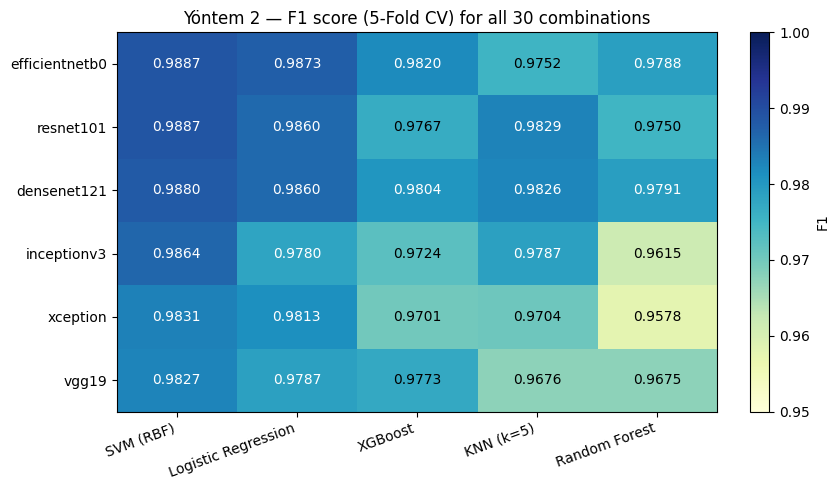

Saved: /content/drive/MyDrive/oruntu_tanima_proje/yontemler/yontem2/grafikler/method2_heatmap_f1.png


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Pivot to 6×5 grid
pivot = df_method2.pivot(index='DL', columns='ML', values='F1')
# Order rows by max F1 desc (best DL on top)
pivot = pivot.loc[pivot.max(axis=1).sort_values(ascending=False).index]
# Order columns by mean F1 desc (best ML on left)
pivot = pivot[pivot.mean(axis=0).sort_values(ascending=False).index]

fig, ax = plt.subplots(figsize=(8.5, 5))
im = ax.imshow(pivot.values, cmap='YlGnBu', vmin=0.95, vmax=1.0, aspect='auto')

ax.set_xticks(range(len(pivot.columns))); ax.set_xticklabels(pivot.columns, rotation=20, ha='right')
ax.set_yticks(range(len(pivot.index)));   ax.set_yticklabels(pivot.index)

for i in range(pivot.shape[0]):
    for j in range(pivot.shape[1]):
        v = pivot.values[i, j]
        ax.text(j, i, f'{v:.4f}', ha='center', va='center',
                color='white' if v > 0.978 else 'black', fontsize=10)

ax.set_title('Yöntem 2 — F1 score (5-Fold CV) for all 30 combinations')
fig.colorbar(im, ax=ax, fraction=0.046, label='F1')
plt.tight_layout()
out = os.path.join(GRAPHS_DIR, 'method2_heatmap_f1.png')
plt.savefig(out, dpi=120, bbox_inches='tight'); plt.show()
print(f'Saved: {out}')

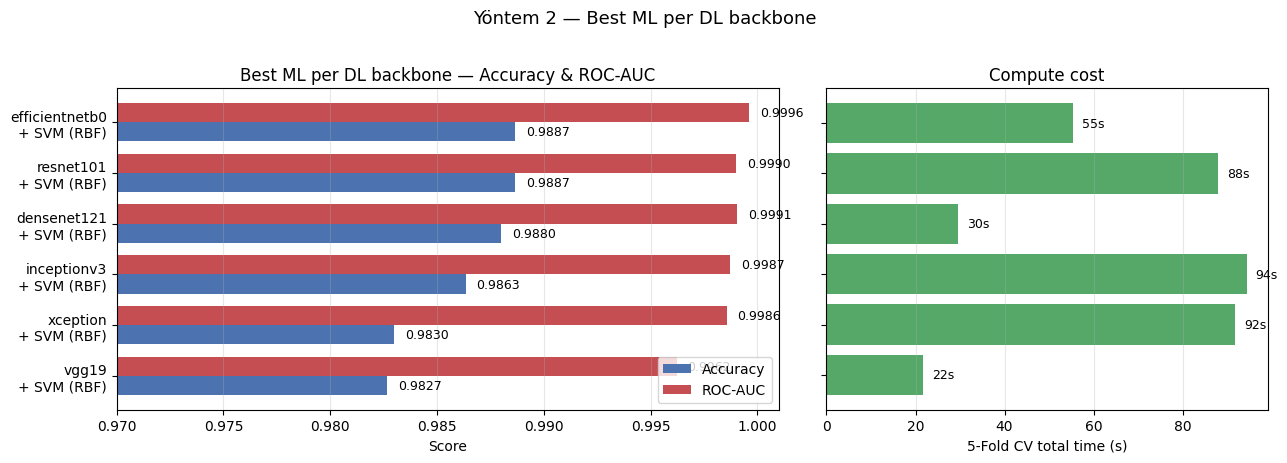

Saved: /content/drive/MyDrive/oruntu_tanima_proje/yontemler/yontem2/grafikler/method2_best_per_dl.png


In [ ]:
best_per_dl = (df_method2.sort_values('F1', ascending=False)
                          .groupby('DL').head(1)
                          .sort_values('F1', ascending=True))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4.5),
                                gridspec_kw={'width_ratios': [1.5, 1]})

y = np.arange(len(best_per_dl))
acc = best_per_dl['Accuracy'].values
auc = best_per_dl['ROC-AUC'].values
t   = best_per_dl['Total (s)'].values
labels_y = [f'{dl}\n+ {ml}' for dl, ml in zip(best_per_dl['DL'], best_per_dl['ML'])]
h = 0.38

ax1.barh(y - h/2, acc, h, label='Accuracy', color='#4C72B0')
ax1.barh(y + h/2, auc, h, label='ROC-AUC',  color='#C44E52')
for i, v in enumerate(acc): ax1.text(v + 0.0005, i - h/2, f'{v:.4f}', va='center', fontsize=9)
for i, v in enumerate(auc): ax1.text(v + 0.0005, i + h/2, f'{v:.4f}', va='center', fontsize=9)
ax1.set_yticks(y); ax1.set_yticklabels(labels_y)
ax1.set_xlim(0.97, 1.001); ax1.set_xlabel('Score')
ax1.set_title('Best ML per DL backbone — Accuracy & ROC-AUC')
ax1.legend(loc='lower right'); ax1.grid(axis='x', alpha=0.3)

ax2.barh(y, t, color='#55A868')
for i, v in enumerate(t): ax2.text(v + 2, i, f'{v:.0f}s', va='center', fontsize=9)
ax2.set_yticks(y); ax2.set_yticklabels([])
ax2.set_xlabel('5-Fold CV total time (s)'); ax2.set_title('Compute cost')
ax2.grid(axis='x', alpha=0.3)

fig.suptitle('Yöntem 2 — Best ML per DL backbone', fontsize=13, y=1.02)
plt.tight_layout()
out = os.path.join(GRAPHS_DIR, 'method2_best_per_dl.png')
plt.savefig(out, dpi=120, bbox_inches='tight'); plt.show()
print(f'Saved: {out}')

Best combo: efficientnetb0 + SVM (RBF)
  Acc=0.9887  F1=0.9887  ROC-AUC=0.9996


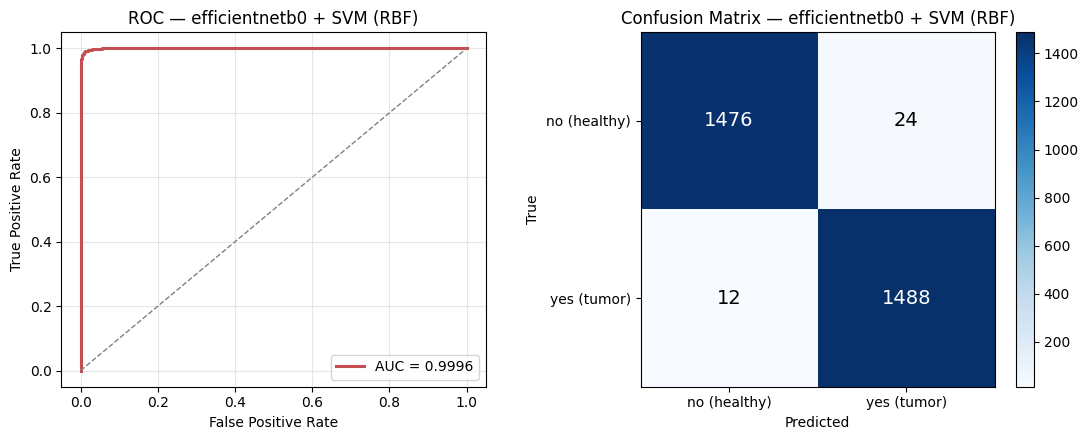

Saved: /content/drive/MyDrive/oruntu_tanima_proje/yontemler/yontem2/grafikler/method2_best_efficientnetb0_SVM_(RBF)_roc_cm.png

Confusion matrix [TN FP / FN TP]:
[[1476   24]
 [  12 1488]]
FN=12/1500  FP=24/1500  (across all 5 folds = 3000 predictions)


In [ ]:
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import roc_curve, auc, confusion_matrix

# Best by F1, then ROC-AUC as tie-breaker
best = df_method2.sort_values(['F1', 'ROC-AUC'], ascending=False).iloc[0]
best_dl, best_ml = best['DL'], best['ML']
print(f'Best combo: {best_dl} + {best_ml}')
print(f'  Acc={best["Accuracy"]:.4f}  F1={best["F1"]:.4f}  ROC-AUC={best["ROC-AUC"]:.4f}')

X_best = np.load(os.path.join(FEAT_DIR, f'feat_{best_dl}.npy'))
pipe_best = ML_MODELS[best_ml]

# Cross-validated probabilities and predictions
y_proba = cross_val_predict(pipe_best, X_best, labels, cv=cv,
                             method='predict_proba', n_jobs=-1)[:, 1]
y_pred  = (y_proba >= 0.5).astype(int)

# --- ROC curve ---
fpr, tpr, _ = roc_curve(labels, y_proba)
roc_auc = auc(fpr, tpr)

fig, (axL, axR) = plt.subplots(1, 2, figsize=(11, 4.5))
axL.plot(fpr, tpr, color='#C44E52', lw=2.2, label=f'AUC = {roc_auc:.4f}')
axL.plot([0, 1], [0, 1], color='gray', lw=1, linestyle='--')
axL.set_xlabel('False Positive Rate'); axL.set_ylabel('True Positive Rate')
axL.set_title(f'ROC — {best_dl} + {best_ml}')
axL.legend(loc='lower right'); axL.grid(alpha=0.3)

# --- Confusion matrix ---
cm = confusion_matrix(labels, y_pred)
im = axR.imshow(cm, cmap='Blues')
axR.set_xticks([0, 1], ['no (healthy)', 'yes (tumor)'])
axR.set_yticks([0, 1], ['no (healthy)', 'yes (tumor)'])
axR.set_xlabel('Predicted'); axR.set_ylabel('True')
axR.set_title(f'Confusion Matrix — {best_dl} + {best_ml}')
thresh = cm.max() / 2
for i in range(2):
    for j in range(2):
        axR.text(j, i, cm[i, j], ha='center', va='center',
                 color='white' if cm[i, j] > thresh else 'black', fontsize=14)
fig.colorbar(im, ax=axR, fraction=0.046)

plt.tight_layout()
out = os.path.join(GRAPHS_DIR, f'method2_best_{best_dl}_{best_ml.replace(" ","_")}_roc_cm.png')
plt.savefig(out, dpi=120, bbox_inches='tight'); plt.show()
print(f'Saved: {out}')
print(f'\nConfusion matrix [TN FP / FN TP]:\n{cm}')
print(f'FN={cm[1,0]}/1500  FP={cm[0,1]}/1500  (across all 5 folds = 3000 predictions)')

In [6]:
import json, os
import pandas as pd

# FE metadata
with open(os.path.join(FEAT_DIR, 'fe_metadata.json')) as f:
    fe_meta = json.load(f)
meta_df = pd.DataFrame(fe_meta)[['model', 'backbone_last_layer', 'feature_dim', 'extract_time_sec']]
meta_df = meta_df.rename(columns={
    'model':               'DL',
    'backbone_last_layer': 'FE Layer',
    'feature_dim':         'Feature Dim',
    'extract_time_sec':    'FE Time (s)',
})

# Read from the nested location
read_path = os.path.join(METHOD2_DIR, 'sonuc_tablosu', 'sonuc_tablosu.csv')
df = pd.read_csv(read_path)
print('Okundu:', read_path, '| satır:', len(df), '| sütunlar:', list(df.columns))

# Merge
df_merged = df.merge(meta_df, on='DL', how='left')
front_cols = ['DL', 'FE Layer', 'Feature Dim', 'ML']
rest_cols  = [c for c in df_merged.columns if c not in front_cols]
df_merged = df_merged[front_cols + rest_cols]
df_merged['Train+Test (s)'] = (df_merged['CV Fit (s)'] + df_merged['CV Score (s)']).round(2)

# Save to the clean flat location
out_path = os.path.join(METHOD2_DIR, 'sonuc_tablosu.csv')
df_merged.to_csv(out_path, index=False)
print(f'\nKaydedildi: {out_path}')

pd.set_option('display.float_format', lambda v: f'{v:.4f}')
print('\nTop 10 by F1:')
print(df_merged.sort_values('F1', ascending=False).head(10).to_string(index=False))

Okundu: /content/drive/MyDrive/oruntu_tanima_proje/yontemler/yontem2/sonuc_tablosu/sonuc_tablosu.csv | satır: 30 | sütunlar: ['DL', 'ML', 'Accuracy', 'Precision', 'Recall', 'F1', 'F1 Macro', 'F1 Weighted', 'ROC-AUC', 'CV Fit (s)', 'CV Score (s)', 'Total (s)']

Kaydedildi: /content/drive/MyDrive/oruntu_tanima_proje/yontemler/yontem2/sonuc_tablosu.csv

Top 10 by F1:
            DL             FE Layer  Feature Dim                  ML  Accuracy  Precision  Recall     F1  F1 Macro  F1 Weighted  ROC-AUC  CV Fit (s)  CV Score (s)  Total (s)  FE Time (s)  Train+Test (s)
efficientnetb0       top_activation         1280           SVM (RBF)    0.9887     0.9842  0.9933 0.9887    0.9887       0.9887   0.9996     87.2392        8.7292    55.3382     432.2298         95.9700
     resnet101     conv5_block3_out         2048           SVM (RBF)    0.9887     0.9862  0.9913 0.9887    0.9887       0.9887   0.9990    144.1086       19.9502    87.9118      35.9854        164.0600
   densenet121          